# Breast Cancer Subtype Prediction
# Step 3: Feature Selection - Phase 1 (Variance Threshold)
# Goal: Remove constant and quasi-constant features from RNA & Methylation data.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print("✅ Libraries Imported.")

✅ Libraries Imported.


## Define IO Functions

In [2]:
io_dir = '../outputs'

def load_object(filename):
    file_path = os.path.join(io_dir, filename + '.pkl')
    with open(file_path, 'rb') as f:
        return pickle.load(f)

def save_object(obj, filename):
    file_path = os.path.join(io_dir, filename + '.pkl')
    with open(file_path, 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)
    print(f"💾 Saved: {file_path}")

print("✅ IO Functions Ready.")

✅ IO Functions Ready.


## Load Processed Data (From Step 2)

In [3]:
print("Loading processed data...")

try:
    # RNA
    X_train_rna = load_object('X_train_rna')
    X_test_rna = load_object('X_test_rna')
    
    # Methylation
    X_train_meth = load_object('X_train_meth')
    X_test_meth = load_object('X_test_meth')
    
    # Labels
    y_train = load_object('y_train')
    y_test = load_object('y_test')
    
    print("\nData Loaded:")
    print(f"RNA Train: {X_train_rna.shape}")
    print(f"Meth Train: {X_train_meth.shape}")
except FileNotFoundError:
    print("❌ Error: Files not found. Run Preprocessing first.")

Loading processed data...

Data Loaded:
RNA Train: (439, 20155)
Meth Train: (439, 20106)


## 1. Apply Variance Threshold on RNA-Seq
We remove genes with very low variance (threshold = 0.1). These genes are likely noise or constant across all patients.

In [ ]:
print("Filtering RNA-Seq Features...")

var_thresh_rna = VarianceThreshold(threshold=0.1)

X_train_rna_var = var_thresh_rna.fit_transform(X_train_rna)
X_test_rna_var = var_thresh_rna.transform(X_test_rna)

rna_selected_indices = var_thresh_rna.get_support(indices=True)

print(f"Original RNA Features: {X_train_rna.shape[1]}")
print(f"Selected RNA Features: {X_train_rna_var.shape[1]}")
print(f"Removed: {X_train_rna.shape[1] - X_train_rna_var.shape[1]}")

Filtering RNA-Seq Features...
Original RNA Features: 20155
Selected RNA Features: 48
Removed: 20107


## 2. Apply Variance Threshold on Methylation
Methylation values are between 0 and 1. Variance is naturally lower. We use a smaller threshold (e.g., 0.001) to remove constant sites.

In [ ]:
print("Filtering Methylation Features...")

var_thresh_meth = VarianceThreshold(threshold=0.001)

X_train_meth_var = var_thresh_meth.fit_transform(X_train_meth)
X_test_meth_var = var_thresh_meth.transform(X_test_meth)

meth_selected_indices = var_thresh_meth.get_support(indices=True)

print(f"Original Meth Features: {X_train_meth.shape[1]}")
print(f"Selected Meth Features: {X_train_meth_var.shape[1]}")
print(f"Removed: {X_train_meth.shape[1] - X_train_meth_var.shape[1]}")

Filtering Methylation Features...
Original Meth Features: 20106
Selected Meth Features: 20106
Removed: 0


## Validation: Quick Linear Model (LDA)
Let's concatenate the filtered RNA and Methylation data and check if a simple LDA model can predict the subtypes.
This ensures we haven't lost important information.

Validating selected features with LDA...

Classification Report (Variance Filtered Data):
              precision    recall  f1-score   support

        LumA       0.83      0.93      0.88        59
        LumB       0.83      0.60      0.70        25
        Her2       0.86      0.86      0.86         7
       Basal       1.00      1.00      1.00        19

    accuracy                           0.86       110
   macro avg       0.88      0.85      0.86       110
weighted avg       0.86      0.86      0.86       110



<Figure size 600x600 with 0 Axes>

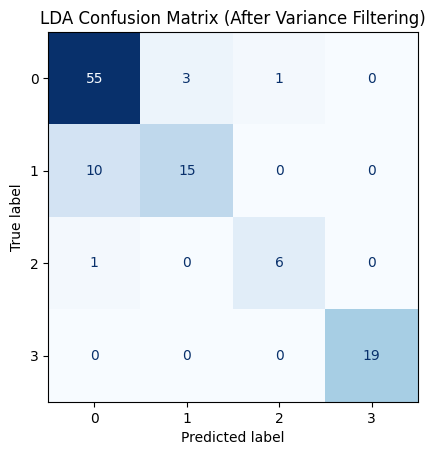

In [ ]:
print("Validating selected features with LDA...")

X_train_combined = np.hstack((X_train_rna_var, X_train_meth_var))
X_test_combined = np.hstack((X_test_rna_var, X_test_meth_var))

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_combined, y_train)

y_pred = lda.predict(X_test_combined)

print("\nClassification Report (Variance Filtered Data):")
print(classification_report(y_test, y_pred, target_names=['LumA', 'LumB', 'Her2', 'Basal']))

plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', colorbar=False)
plt.title("LDA Confusion Matrix (After Variance Filtering)")
plt.show()

## Saving Result
Saving the reduced datasets for the next step (ANOVA/ReliefF).

In [ ]:
print("Saving reduced datasets to '../outputs/'...")

save_object(X_train_rna_var, 'X_train_rna_var')
save_object(X_test_rna_var,  'X_test_rna_var')
save_object(rna_selected_indices, 'feat_indices_rna_var')

save_object(X_train_meth_var, 'X_train_meth_var')
save_object(X_test_meth_var,  'X_test_meth_var')
save_object(meth_selected_indices, 'feat_indices_meth_var')

save_object(y_train, 'y_train')
save_object(y_test,  'y_test')

print("\n🎉 Feature Selection Step 1 Completed.")

Saving reduced datasets to '../outputs/'...
💾 Saved: ../outputs\X_train_rna_var.pkl
💾 Saved: ../outputs\X_test_rna_var.pkl
💾 Saved: ../outputs\feat_indices_rna_var.pkl
💾 Saved: ../outputs\X_train_meth_var.pkl
💾 Saved: ../outputs\X_test_meth_var.pkl
💾 Saved: ../outputs\feat_indices_meth_var.pkl
💾 Saved: ../outputs\y_train.pkl
💾 Saved: ../outputs\y_test.pkl

🎉 Feature Selection Step 1 Completed.
